In [1]:
import sys
import numpy as np
import yaml
import glob
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
%config InlineBackend.figure_format='retina'
plt.style.use('tableau-colorblind10')

In [7]:
list_fits = sorted(glob.glob(f"runs/runs_082126/*/fits/*.fits"))

In [8]:
list_fits

['runs/runs_082126/0/fits/surface_image.fits',
 'runs/runs_082126/1/fits/surface_image.fits',
 'runs/runs_082126/10/fits/surface_image.fits',
 'runs/runs_082126/11/fits/surface_image.fits',
 'runs/runs_082126/12/fits/surface_image.fits',
 'runs/runs_082126/13/fits/surface_image.fits',
 'runs/runs_082126/14/fits/surface_image.fits',
 'runs/runs_082126/15/fits/surface_image.fits',
 'runs/runs_082126/16/fits/surface_image.fits',
 'runs/runs_082126/17/fits/surface_image.fits',
 'runs/runs_082126/18/fits/surface_image.fits',
 'runs/runs_082126/19/fits/surface_image.fits',
 'runs/runs_082126/2/fits/surface_image.fits',
 'runs/runs_082126/20/fits/surface_image.fits',
 'runs/runs_082126/21/fits/surface_image.fits',
 'runs/runs_082126/22/fits/surface_image.fits',
 'runs/runs_082126/23/fits/surface_image.fits',
 'runs/runs_082126/24/fits/surface_image.fits',
 'runs/runs_082126/25/fits/surface_image.fits',
 'runs/runs_082126/26/fits/surface_image.fits',
 'runs/runs_082126/27/fits/surface_image.fi

In [32]:
manifest_path = sorted(glob.glob(f"runs/runs_082126/*.yml"))

In [33]:
manifest_path

['runs/runs_082126/manifest.yml']

In [34]:
days_run = sorted([int(x.split('/')[1].split('_')[1]) for x in manifest_path])

In [35]:
days_run

[82126]

In [36]:
select_day_ran = [x for x in list_fits if str(days_run[-1]) in x]

In [37]:
select_day_ran

['runs/runs_082126/0/fits/surface_image.fits',
 'runs/runs_082126/1/fits/surface_image.fits',
 'runs/runs_082126/10/fits/surface_image.fits',
 'runs/runs_082126/11/fits/surface_image.fits',
 'runs/runs_082126/12/fits/surface_image.fits',
 'runs/runs_082126/13/fits/surface_image.fits',
 'runs/runs_082126/14/fits/surface_image.fits',
 'runs/runs_082126/15/fits/surface_image.fits',
 'runs/runs_082126/16/fits/surface_image.fits',
 'runs/runs_082126/17/fits/surface_image.fits',
 'runs/runs_082126/18/fits/surface_image.fits',
 'runs/runs_082126/19/fits/surface_image.fits',
 'runs/runs_082126/2/fits/surface_image.fits',
 'runs/runs_082126/20/fits/surface_image.fits',
 'runs/runs_082126/21/fits/surface_image.fits',
 'runs/runs_082126/22/fits/surface_image.fits',
 'runs/runs_082126/23/fits/surface_image.fits',
 'runs/runs_082126/24/fits/surface_image.fits',
 'runs/runs_082126/25/fits/surface_image.fits',
 'runs/runs_082126/26/fits/surface_image.fits',
 'runs/runs_082126/27/fits/surface_image.fi

In [38]:
params_path = select_day_ran[0].replace('fits/surface_image.fits', 'run_params.yml') #it does not matter which one
params_path


'runs/runs_082126/0/run_params.yml'

In [39]:
with open(params_path, "r") as f:
    data = yaml.safe_load(f)

In [40]:
data

{'so_d_ly': 154940.4078,
 'dz0_ly': 1.5655487999999997,
 'ct_years': 0.6849325,
 'a': 0.306,
 'ay': 0.361,
 'az': 1,
 'z0ly': 272.78383216,
 'angles_deg': [335, -94],
 'wavel': 0.434,
 'path_csv_lc': 'LEIMG/data/lightcurves/LC_sn2011fe.csv',
 'pixel_resolution': 0.2,
 'dust_env': 'lmc',
 'composition_s_c': 'both'}

In [41]:
manifest_path

['runs/runs_082126/manifest.yml']

In [42]:
with open(manifest_path[0], "r") as f:
    data = yaml.safe_load(f)

In [43]:
data

[{'run_id': 0,
  'outputs': ['runs/runs_082126/0/arrays/surface.npy',
   'runs/runs_082126/0/arrays/surface_values.npy',
   'runs/runs_082126/0/arrays/ximg_arcsec.npy',
   'runs/runs_082126/0/arrays/yimg_arcsec.npy',
   'runs/runs_082126/0/arrays/zimgly.npy',
   'runs/runs_082126/0/arrays/x_ly.npy',
   'runs/runs_082126/0/arrays/y_ly.npy',
   'runs/runs_082126/0/arrays/z_ly.npy'],
  'meta': {'run_id': 0,
   'n_phases': 11,
   'ct_years': 0.6849325,
   'params': {'so_d_ly': 154940.4078,
    'dz0_ly': 1.5655487999999997,
    'ct_years': 0.6849325,
    'a': 0.306,
    'ay': 0.361,
    'az': 1,
    'z0ly': 272.78383216,
    'angles_deg': [335, -94],
    'wavel': 0.434,
    'path_csv_lc': 'LEIMG/data/lightcurves/LC_sn2011fe.csv',
    'pixel_resolution': 0.2,
    'dust_env': 'lmc',
    'composition_s_c': 'both'}}},
 {'run_id': 1,
  'outputs': ['runs/runs_082126/1/arrays/surface.npy',
   'runs/runs_082126/1/arrays/surface_values.npy',
   'runs/runs_082126/1/arrays/ximg_arcsec.npy',
   'runs/r

In [44]:
params =[
    'so_d_ly',
    'dz0_ly',
    'ct_years',
    'a',
    'ay',
    'az',
    'z0ly',
    'angles_deg',
    'wavel',
    'dust_env',
    'composition_s_c']

# Load all data

In [45]:
def create(manifest_path_ix):
    with open(manifest_path_ix, "r") as f:
        data = yaml.safe_load(f)
    df = pd.DataFrame(data)
    df['outputs'] = df['outputs'].apply(lambda x: x[0])
    df['ct_years'] = df['meta'].apply(lambda x: x['ct_years'])
    for pix in params:
        df[pix] = df['meta'].apply(lambda x: x['params'][pix])
    df.drop(columns=['meta'])

    return df

In [46]:
df_all = pd.DataFrame()
for mm in manifest_path:
    df = create(mm)
    df_all = pd.concat([df_all, df])

In [47]:
df_all

,run_id,outputs,meta,ct_years,so_d_ly,dz0_ly,a,ay,az,z0ly,angles_deg,wavel,dust_env,composition_s_c
0,0,runs/runs_082126/0/arrays/surface.npy,"{'run_id': 0, 'n_phases': 11, 'ct_years': 0.68...",0.684933,154940.40780,1.565549,0.306,0.361,1,272.783832,"[335, -94]",0.434,lmc,both
1,1,runs/runs_082126/1/arrays/surface.npy,"{'run_id': 1, 'n_phases': 12, 'ct_years': 0.95...",0.958906,154940.40780,1.565549,0.306,0.361,1,272.783832,"[335, -94]",0.434,lmc,both
2,2,runs/runs_082126/2/arrays/surface.npy,"{'run_id': 2, 'n_phases': 12, 'ct_years': 1.23...",1.232878,154940.40780,1.565549,0.306,0.361,1,272.783832,"[335, -94]",0.434,lmc,both
3,3,runs/runs_082126/3/arrays/surface.npy,"{'run_id': 3, 'n_phases': 12, 'ct_years': 1.50...",1.506852,154940.40780,1.565549,0.306,0.361,1,272.783832,"[335, -94]",0.434,lmc,both
4,4,runs/runs_082126/4/arrays/surface.npy,"{'run_id': 4, 'n_phases': 12, 'ct_years': 1.78...",1.780825,154940.40780,1.565549,0.306,0.361,1,272.783832,"[335, -94]",0.434,lmc,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,runs/runs_082126/65/arrays/surface.npy,"{'run_id': 65, 'n_phases': 12, 'ct_years': 1.2...",1.232878,175892.66924,1.826474,0.009,0.233,1,50.407410,"[31, -17]",0.434,mw,both
66,66,runs/runs_082126/66/arrays/surface.npy,"{'run_id': 66, 'n_phases': 12, 'ct_years': 1.5...",1.506852,175892.66924,1.826474,0.009,0.233,1,50.407410,"[31, -17]",0.434,mw,both
67,67,runs/runs_082126/67/arrays/surface.npy,"{'run_id': 67, 'n_phases': 12, 'ct_years': 1.7...",1.780825,175892.66924,1.826474,0.009,0.233,1,50.407410,"[31, -17]",0.434,mw,both
68,68,runs/runs_082126/68/arrays/surface.npy,"{'run_id': 68, 'n_phases': 12, 'ct_years': 2.0...",2.054798,175892.66924,1.826474,0.009,0.233,1,50.407410,"[31, -17]",0.434,mw,both


In [48]:
df_all.columns

Index(['run_id', 'outputs', 'meta', 'ct_years', 'so_d_ly', 'dz0_ly', 'a', 'ay',
       'az', 'z0ly', 'angles_deg', 'wavel', 'dust_env', 'composition_s_c'],
      dtype='str')

In [49]:
df_all = df_all.sort_values(by=['ct_years'])

# Group by params, each row is one system simulated at different times

In [50]:
df_to_use_to_plot_single_double = df_all.groupby(['so_d_ly',  'a', 'ay',
       'az', 'z0ly', 'wavel', 'dz0_ly']).agg({'ct_years': list, 'angles_deg': list, 'outputs':list})

In [51]:
df_to_use_to_plot_single_double

,,,,,,,ct_years,angles_deg,outputs
so_d_ly,a,ay,az,z0ly,wavel,dz0_ly,,,
15251.05456,0.367,0.015,1,148.254210,0.434,0.163078,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[245, -344], [245, -344], [245, -344], [245, ...","[runs/runs_082126/35/arrays/surface.npy, runs/..."
16999.25072,0.342,0.312,1,166.042758,0.323,3.131098,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[201, -282], [201, -282], [201, -282], [201, ...","[runs/runs_082126/21/arrays/surface.npy, runs/..."
29220.31604,0.088,0.173,1,189.764084,0.711,2.804942,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[78, 102], [78, 102], [78, 102], [78, 102], [...","[runs/runs_082126/56/arrays/surface.npy, runs/..."
46682.70828,0.015,0.155,1,263.889558,0.545,1.826474,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[201, -283], [201, -283], [201, -283], [201, ...","[runs/runs_082126/28/arrays/surface.npy, runs/..."
51920.77364,0.397,0.167,1,308.364190,0.656,1.630780,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[263, -44], [263, -44], [263, -44], [263, -44...","[runs/runs_082126/7/arrays/surface.npy, runs/r..."
71128.10048,0.342,0.270,1,118.603368,0.267,1.108930,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[58, 155], [58, 155], [58, 155], [58, 155], [...","[runs/runs_082126/42/arrays/surface.npy, runs/..."
90332.16576,0.258,-0.045,1,281.681368,0.711,0.848006,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[49, 105], [49, 105], [49, 105], [49, 105], [...","[runs/runs_082126/14/arrays/surface.npy, runs/..."
93825.29652,0.112,0.306,1,183.834568,0.767,2.739710,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[224, 244], [224, 244], [224, 244], [224, 244...","[runs/runs_082126/49/arrays/surface.npy, runs/..."
154940.40780,0.306,0.361,1,272.783832,0.434,1.565549,"[0.6849325, 0.9589055000000001, 1.2328785, 1.5...","[[335, -94], [335, -94], [335, -94], [335, -94...","[runs/runs_082126/0/arrays/surface.npy, runs/r..."


# Get a) plot t0 for each system

In [52]:
df_to_use_to_plot_single_double_save = df_all.groupby(['so_d_ly',  'a', 'ay',
       'az', 'z0ly', 'wavel', 'dz0_ly']).agg({'ct_years': 'first', 'outputs':'first'}).reset_index(drop=True)

In [53]:
df_to_use_to_plot_single_double_save['name_npy'] = ''

In [54]:
df_to_use_to_plot_single_double_save

,ct_years,outputs,name_npy
0,0.684933,runs/runs_082126/35/arrays/surface.npy,
1,0.684933,runs/runs_082126/21/arrays/surface.npy,
2,0.684933,runs/runs_082126/56/arrays/surface.npy,
3,0.684933,runs/runs_082126/28/arrays/surface.npy,
4,0.684933,runs/runs_082126/7/arrays/surface.npy,
5,0.684933,runs/runs_082126/42/arrays/surface.npy,
6,0.684933,runs/runs_082126/14/arrays/surface.npy,
7,0.684933,runs/runs_082126/49/arrays/surface.npy,
8,0.684933,runs/runs_082126/0/arrays/surface.npy,
9,0.684933,runs/runs_082126/63/arrays/surface.npy,


In [55]:
for ix, row in df_to_use_to_plot_single_double_save.iterrows():
    if ix > 0:
        break
    which_fits = row['outputs'].replace('arrays', 'fits').replace('surface.npy', 'surface_image.fits')
    fits_img = fits.open(which_fits)[0].data
    mags_plot = -2.5*np.log10(fits_img)-48.6
    mags_plot = np.nan_to_num(mags_plot, nan=0.0, posinf=0.0, neginf=0.0)

/tmp/ipykernel_1023594/2229611934.py:6: RuntimeWarning: divide by zero encountered in log10
  mags_plot = -2.5*np.log10(fits_img)-48.6


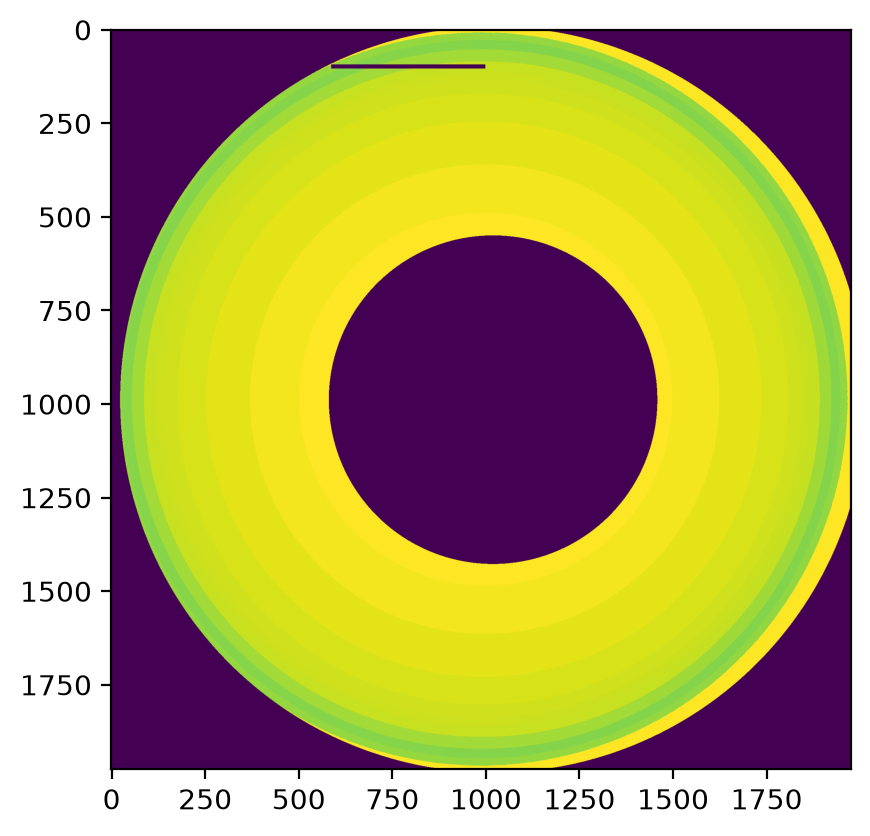

In [56]:
plt.imshow(mags_plot)

In [57]:
fits_img.max() > 1

np.False_

In [58]:
which_fits

'runs/runs_082126/35/fits/surface_image.fits'

In [26]:
from itertools import combinations

# Get c) plot t1-t0 for each system, you need two LE, one at t0 and other at t1 for the same system

In [27]:
def create_pairs_dtimeonly(ixy):
    
    indexed_list = list(enumerate(df_to_use_to_plot_single_double.iloc[ixy]['ct_years']))

    all_perms = list(set(sorted(combinations(indexed_list, 2))))
    result = [
        {
            "pair": (elem1, elem2), 
            "indices": (idx1, idx2)
        } 
        for (idx1, elem1), (idx2, elem2) in all_perms
    ]

    df_one = pd.DataFrame(index=range(len(result)), columns=['pair_time_ct_years','outputs', 'name_npy'])
    for ix, pp in enumerate(result):
        index = pp['indices']
        
        o_array = np.array(df_to_use_to_plot_single_double.iloc[ixy]['outputs'])
        df_one.loc[ix, 'pair_time_ct_years'] = pp['pair']
        # df_one.loc[ix, 'indices'] = pp['indices']
        df_one.loc[ix, 'outputs'] = o_array[np.array(index)]
        df_one.loc[ix, 'name_npy'] = ''
        
        # print(o_array[np.array(index)])
    return df_one


In [28]:
df_to_use_to_plot_single_double_save = pd.DataFrame()
for ix in range(len(df_to_use_to_plot_single_double)):
    # print(ix)
    df_one = create_pairs_dtimeonly(ix)
    df_to_use_to_plot_single_double_save = pd.concat([df_to_use_to_plot_single_double_save, df_one])


In [29]:
df_to_use_to_plot_single_double_save

,pair_time_ct_years,outputs,name_npy
0,"(1.5068515, 2.0547975000000003)","[runs/runs_07142026/0003/3/arrays/surface.npy,...",
1,"(0.9589055000000001, 2.0547975000000003)","[runs/runs_07142026/0003/1/arrays/surface.npy,...",
2,"(1.2328785, 2.0547975000000003)","[runs/runs_07142026/0003/2/arrays/surface.npy,...",
3,"(0.9589055000000001, 1.5068515)","[runs/runs_07142026/0003/1/arrays/surface.npy,...",
4,"(0.9589055000000001, 1.2328785)","[runs/runs_07142026/0003/1/arrays/surface.npy,...",
...,...,...,...
10,"(1.2328785, 1.7808245)","[runs/runs_07152026/0001/2/arrays/surface.npy,...",
11,"(0.6849325, 1.5068515)","[runs/runs_07152026/0001/0/arrays/surface.npy,...",
12,"(0.6849325, 1.2328785)","[runs/runs_07152026/0001/0/arrays/surface.npy,...",
13,"(1.7808245, 2.0547975000000003)","[runs/runs_07152026/0001/4/arrays/surface.npy,...",


# Get b) plot t0 for two different systems, but t0=t0 at each system: You need two LE, each at t0

In [30]:
# df_to_use_to_plot_single_double = df_all.groupby(['so_d_ly',  'a', 'ay',
#        'az', 'z0ly', 'wavel', 'dz0_ly']).agg({'ct_years': list, 'angles_deg': list, 'outputs':list})

In [31]:
df_to_use_to_plot_double = df_all.groupby(['so_d_ly', 'wavel','ct_years']).agg({'outputs':list, 'z0ly':list})

In [32]:
df_to_use_to_plot_double['mask'] = df_to_use_to_plot_double['outputs'].apply(lambda x: True if len(x)>1 else False)
df_to_use_to_plot_double['mask2'] = df_to_use_to_plot_double['z0ly'].apply(lambda x: True if len(set(x))>1 else False)

In [33]:
df_to_use_to_plot_double = df_to_use_to_plot_double[(df_to_use_to_plot_double['mask'] == True) & (df_to_use_to_plot_double['mask2'] == True)]

In [34]:
df_to_use_to_plot_double

outputs  \
so_d_ly   wavel ct_years                                                      
169601.12 0.567 0.684933  [runs/runs_07142026/0001/0/arrays/surface.npy,...   
                0.958906  [runs/runs_07152026/0001/1/arrays/surface.npy,...   
                1.232878  [runs/runs_07152026/0001/2/arrays/surface.npy,...   
                1.506852  [runs/runs_07142026/0001/3/arrays/surface.npy,...   
                1.780825  [runs/runs_07142026/0002/4/arrays/surface.npy,...   
                2.054798  [runs/runs_07142026/0002/5/arrays/surface.npy,...   

                                                            z0ly  mask  mask2  
so_d_ly   wavel ct_years                                                       
169601.12 0.567 0.684933  [228.30919999999998, 163.078, 326.156]  True   True  
                0.958906  [326.156, 228.30919999999998, 163.078]  True   True  
                1.232878  [326.156, 228.30919999999998, 163.078]  True   True  
                1.506852  [228.30919999999998, 163.078, 326.156]  True   True  
                1.780825  [163.078, 228.30919999999998, 326.156]  True   True  
                2.054798  [163.078, 326.156, 228.30919999999998]  True   True

In [36]:
def create_pairs_dtime_twosystem_only(ixy):
    
    indexed_list = list(enumerate(df_to_use_to_plot_double.iloc[ixy]['outputs']))

    all_perms = list(set(sorted(combinations(indexed_list, 2))))
    result = [
        {
            "pair": (elem1, elem2), 
            "indices": (idx1, idx2)
        } 
        for (idx1, elem1), (idx2, elem2) in all_perms
    ]

    df_one = pd.DataFrame(index=range(len(result)), columns=['ct_years','outputs', 'name_npy'])
    for ix, pp in enumerate(result):
        df_one.loc[ix, 'ct_years'] = df_to_use_to_plot_double.index[ixy][-1]
        # df_one.loc[ix, 'indices'] = pp['indices']
        df_one.loc[ix, 'outputs'] = pp['pair']
        df_one.loc[ix, 'name_npy'] = ''
    return df_one
df_to_use_to_plot_double_save = pd.DataFrame()
for ix in range(len(df_to_use_to_plot_double)):
    # print(ix)
    df_one = create_pairs_dtime_twosystem_only(ix)
    df_to_use_to_plot_double_save = pd.concat([df_to_use_to_plot_double_save, df_one])

In [37]:
df_to_use_to_plot_double_save

,ct_years,outputs,name_npy
0,0.684933,"(runs/runs_07142026/0001/0/arrays/surface.npy,...",
1,0.684933,"(runs/runs_07142026/0002/0/arrays/surface.npy,...",
2,0.684933,"(runs/runs_07142026/0001/0/arrays/surface.npy,...",
0,0.958906,"(runs/runs_07152026/0001/1/arrays/surface.npy,...",
1,0.958906,"(runs/runs_07152026/0001/1/arrays/surface.npy,...",
2,0.958906,"(runs/runs_07142026/0001/1/arrays/surface.npy,...",
0,1.232878,"(runs/runs_07152026/0001/2/arrays/surface.npy,...",
1,1.232878,"(runs/runs_07142026/0001/2/arrays/surface.npy,...",
2,1.232878,"(runs/runs_07152026/0001/2/arrays/surface.npy,...",
0,1.506852,"(runs/runs_07142026/0001/3/arrays/surface.npy,...",


# Get d) plot t1-t0 for two systems: You need 4 LEs, 2 at t0 and 2 at t1

In [38]:
def create_pairs_dtime_twosystem(df_to_use_to_plot_single_double, df_to_use_to_plot_double):

    df_to_use_to_plot_double_double = df_to_use_to_plot_single_double.reset_index()
    so_d_to_use = list(set([x[0] for x in df_to_use_to_plot_double.index]))
    df_to_use_double_double  = df_to_use_to_plot_double_double[df_to_use_to_plot_double_double['so_d_ly'].isin(so_d_to_use)]
    years = []
    for ix, row in df_to_use_double_double.iterrows():
        years.extend(row['ct_years'])
    all_perms = list(combinations(sorted(set(years)), 2))

    rr = []
    for yy in all_perms:
        for ix, row in df_to_use_double_double.iterrows():
            for iy, rowy in df_to_use_double_double.iterrows():
                if iy > ix:
            
                    indxy = np.where(np.array(rowy['ct_years']) == yy[0])
                    indx = np.where(np.array(row['ct_years']) == yy[0])
        
                    indxy2 = np.where(np.array(rowy['ct_years']) == yy[1])
                    indx2 = np.where(np.array(row['ct_years']) == yy[1])
                    if len(indx) & len(indxy) & len(indx2) & len(indxy2) == 1:
                        pathy = rowy['outputs'][indxy[0][0]]
                        path = row['outputs'][indx[0][0]]
        
                        pathy2 = rowy['outputs'][indxy2[0][0]]
                        path2 = row['outputs'][indx2[0][0]]
                        rr.append([path, pathy, path2, pathy2, yy])

    df_all_here = pd.DataFrame()
    df_all_here['pair_time_ct_years'] = [x[-1] for x in rr]
    # df_one['indices'] = pp['indices']
    df_all_here['outputs'] = [x[:-1] for x in rr]
    df_all_here['name_npy'] = ''

    return df_all_here


In [39]:
df_all_here = create_pairs_dtime_twosystem(df_to_use_to_plot_single_double, df_to_use_to_plot_double)

In [40]:
df_all_here

,pair_time_ct_years,outputs,name_npy
0,"(0.6849325, 0.9589055000000001)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
1,"(0.6849325, 0.9589055000000001)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
2,"(0.6849325, 0.9589055000000001)","[runs/runs_07142026/0001/0/arrays/surface.npy,...",
3,"(0.6849325, 1.2328785)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
4,"(0.6849325, 1.2328785)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
5,"(0.6849325, 1.2328785)","[runs/runs_07142026/0001/0/arrays/surface.npy,...",
6,"(0.6849325, 1.5068515)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
7,"(0.6849325, 1.5068515)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
8,"(0.6849325, 1.5068515)","[runs/runs_07142026/0001/0/arrays/surface.npy,...",
9,"(0.6849325, 1.7808245)","[runs/runs_07142026/0002/0/arrays/surface.npy,...",
